In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from scipy import integrate

In [5]:
mx = 192
mt = 1000
n = 40

In [6]:
#x = np.linspace(0, 1, m2)

t_min = 20.0
t_max = 100.0
tau = 0.1
y_space = np.linspace(t_min+tau/2, t_max+tau/2, mt)
#t_4_Ef = np.arange(t_min + tau/2, t_max + tau/2, tau)
#x = np.linspace(t_min+tau/2, t_max+tau/2, m2)
#x = np.linspace(0, x_range, mx)

x_min = 1
x_max = 3.2
dx = .02
#x = np.arange(x_min, x_max + dx/2, dx)
x_space = np.linspace(x_min, x_max + dx/2, mx)

In [7]:
np.shape(y_space)

(1000,)

In [8]:
np.shape(x_space)

(192,)

In [9]:
import scipy.io as sio
import os

#cwd = os.getcwd()
#os.chdir(cwd)
path = '/home/saumya/NeuralN/deepxsede/spyder tries'
os.environ['PATH'] += ':'+path


mat = sio.loadmat('data_4_training_Ef_1000.mat')    #loading data sets with prob >= 0.99 and not noisy
V = mat['V_train']
Ef = mat['Ef_train']

In [10]:
V = V[:n,:]
Ef = Ef[:n,:]

In [11]:
print(np.shape(V))
print(np.shape(V[1,:]))
print(np.shape(Ef))
print(np.shape(Ef[1,:]))

(40, 192)
(192,)
(40, 1000)
(1000,)


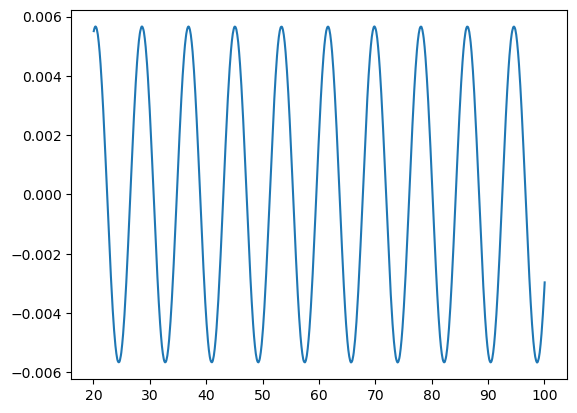

In [47]:
plt.plot(y, Ef[1, :])

In [48]:
U_in = np.zeros((mx,n))
U = np.zeros((mx,mt,n))

for ni in range(n):
    x_values = V[ni, :]
    U_in[:,ni] = x_values
    for tt in range(mt):
        U[:,tt,ni] = x_values

In [51]:
#def integrate_data(m1=m1, m2=m2, n=n, x=x, U=V, S=Ef):
#    us = np.zeros((m2*n, m1))
#    xs = np.zeros((m2*n, 1))
#    ss = np.zeros((m2*n, 1))
#    for i in range(n):
#        for j in range(m2):
#            us[i*m2+j, :] = V[i, :]
#            xs[i*m2+j, :] = x[j]
#            ss[i*m2+j, :] = Ef[i, j]
#    return us, xs, ss

def interate_dataset(mx=mx, mt=mt, n=n, x=x, U_in=U_in, U=V, S=Ef):
    us = np.zeros((mx*mt*n, mx))
    xs = np.zeros((mx*mt*n, 2))
    ss = np.zeros((mx*mt*n, 1))
    count = 0
    for i in range(n):
        for j in range(mx):
            for jj in range(mt):
                us[count,:] = U_in[:,i]
                xs[count] = [x_space[j],y_space[jj]]
                ss[count] = Ef[i, j]
                count = count+1
                
    return us, xs, ss

In [52]:
us,xs,ss = interate_dataset()
print(us.shape, xs.shape, ss.shape)

(7680000, 192) (7680000, 2) (7680000, 1)


In [53]:
def batch_dataset(batch_size, mx=mx, mt=mt, n=n, x=x, U=V, S=Ef, ratio=0.8):
    us, xs, ss = interate_dataset(mx=mx, mt=mt, n=n, x=x, U_in=U_in, U=V, S=Ef)
    
    train_size = int(len(us)*ratio)
    
    us_train = us[:train_size]
    xs_train = xs[:train_size]
    ss_train = ss[:train_size]
    
    us_test = us[train_size:]
    xs_test = xs[train_size:]
    ss_test = ss[train_size:]
    
    us_train = torch.tensor(us_train, dtype= torch.float32)
    xs_train = torch.tensor(xs_train, dtype= torch.float32)
    ss_train = torch.tensor(ss_train, dtype= torch.float32)
    train_dataset = torch.utils.data.TensorDataset(us_train,xs_train,ss_train)
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    us_test = torch.tensor(us_test, dtype= torch.float32)
    xs_test = torch.tensor(xs_test, dtype= torch.float32)
    ss_test = torch.tensor(ss_test, dtype= torch.float32)
    test_dataset = torch.utils.data.TensorDataset(us_test,xs_test,ss_test)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
    
    
    return train_dataloader, test_dataloader

In [54]:
train_data, test_data = batch_dataset(batch_size=32, ratio=0.9)

In [15]:
#for u_batch, x_batch, s_batch in train_data:
#    print(u_batch, x_batch, s_batch)

In [55]:
import torch.nn as nn

class DeepONet(nn.Module):
    def __init__(self, neurons=40, in1 = mx, in2= 2, output_neurons =20):
        super(DeepONet, self).__init__()
        self.neurons = neurons
        self.duble_neurons = 2*neurons
        self.in1 = in1
        self.in2 = in2
        self.output_neurons = output_neurons
        self.branch = self.branch_network()
        self.trunk = self.trunk_network()
        
    def branch_network(self):
        branch = nn.Sequential(
            nn.Linear(self.in1,self.duble_neurons),
            nn.ReLU(),
            nn.Linear(self.duble_neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.output_neurons),
        )
        return branch
        
    def trunk_network(self):
        trunk=nn.Sequential(
            nn.Linear(self.in2,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.neurons),
            nn.ReLU(),
            nn.Linear(self.neurons,self.output_neurons),
        )
        return trunk
        
    def forward(self, x1, x2):
        x1 = self.branch(x1)
        x2 = self.trunk(x2)
        x = torch.einsum("bi, bi->b", x1,x2)
        x = torch.unsqueeze(x,1)
        return x

In [56]:
model = DeepONet(neurons=40, in1 = mx, in2= 2, output_neurons =20)

In [57]:
#model.eval()

In [60]:
def loss(y_pred, y):
    return torch.mean((y_pred - y)**2)

In [61]:
optimizer = torch.optim.Adam(model.parameters(), lr=.001)

In [62]:
import torch.nn as nn
import torch.optim as optim

train_looses = []

def closure():
    optimizer.zero_grad()
    l_total = 0
    
    for u_, x_, s_ in train_data:
        model.train()
        y_pred = model(u_, x_)
        l = loss(y_pred, s_)
        l_total += l.item()
        l.backward()
    
    l_total = l_total/ len(train_data)
    train_looses.append(l_total)
    
    return l_total

epochs = 600

for i in range(epochs):
    optimizer.step(closure)
    
    if i%20 == 0:
        print("Epoch", i, " / ", epochs, "loss ", train_looses[-1])


Epoch 0  /  600 loss  7.10670516514447
Epoch 20  /  600 loss  0.04657045426319086
Epoch 40  /  600 loss  0.0061658803681359
Epoch 60  /  600 loss  0.0018665894009241633
Epoch 80  /  600 loss  0.0011838249096740414
Epoch 100  /  600 loss  0.0007841593017732251
Epoch 120  /  600 loss  0.0005770613171287685
Epoch 140  /  600 loss  0.00046561437875509537
Epoch 160  /  600 loss  0.00039653116145048746
Epoch 180  /  600 loss  0.0003485731343164136
Epoch 200  /  600 loss  0.0003130583346897361
Epoch 220  /  600 loss  0.0002863101216093195
Epoch 240  /  600 loss  0.00026432240112771307
Epoch 260  /  600 loss  0.0002458105345409691
Epoch 280  /  600 loss  0.00023003083965591873
Epoch 300  /  600 loss  0.00021629347906860453
Epoch 320  /  600 loss  0.00020410662278172147
Epoch 340  /  600 loss  0.00019348326379945826
Epoch 360  /  600 loss  0.0001842270994423382
Epoch 380  /  600 loss  0.00017585086588954894
Epoch 400  /  600 loss  0.00016829995830298854
Epoch 420  /  600 loss  0.000161474220006

In [2]:
plt.plot(train_looses)

NameError: name 'plt' is not defined

In [64]:
u_t = V[20,:]
s_t = Ef[20,:]

In [65]:
model.eval()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=192, out_features=80, bias=True)
    (1): ReLU()
    (2): Linear(in_features=80, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=20, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=2, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=20, bias=True)
  )
)

In [66]:
u_t_tens = torch.tensor(u_t, dtype = torch.float32)
#print(u_t_tens)
u_t_tens = torch.tensor(u_t, dtype = torch.float32).unsqueeze(0)
#print(u_t_tens)
x_tens = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
#print(x_tens)

In [67]:
print(u_t_tens.shape)

torch.Size([1, 192])


In [69]:
print(x_tens.shape)

torch.Size([192, 1])


In [70]:
p = model(u_t_tens, x_tens)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (192x1 and 2x40)

In [28]:
print(p)

tensor([[-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5.4305e-07],
        [-5

In [29]:
print(u_t_tens)

tensor([[-1.4492e-06, -1.9664e-06, -2.6622e-06, -3.5957e-06, -4.8449e-06,
         -6.5121e-06, -8.7312e-06, -1.1676e-05, -1.5574e-05, -2.0718e-05,
         -2.7485e-05, -3.6361e-05, -4.7968e-05, -6.3098e-05, -8.2758e-05,
         -1.0822e-04, -1.4110e-04, -1.8340e-04, -2.3765e-04, -3.0699e-04,
         -3.9531e-04, -5.0742e-04, -6.4923e-04, -8.2800e-04, -1.0525e-03,
         -1.3336e-03, -1.6841e-03, -2.1196e-03, -2.6589e-03, -3.3241e-03,
         -4.1416e-03, -5.1427e-03, -6.3641e-03, -7.8485e-03, -9.6458e-03,
         -1.1814e-02, -1.4419e-02, -1.7539e-02, -2.1259e-02, -2.5678e-02,
         -3.0909e-02, -3.7075e-02, -4.4317e-02, -5.2788e-02, -6.2660e-02,
         -7.4119e-02, -8.7368e-02, -1.0263e-01, -1.2013e-01, -1.4014e-01,
         -1.6290e-01, -1.8872e-01, -2.1787e-01, -2.5066e-01, -2.8741e-01,
         -3.2841e-01, -3.7400e-01, -4.2449e-01, -4.8018e-01, -5.4137e-01,
         -6.0837e-01, -6.8144e-01, -7.6084e-01, -8.4681e-01, -9.3958e-01,
         -1.0393e+00, -1.1463e+00, -1.

In [30]:
p=p.detach().numpy()

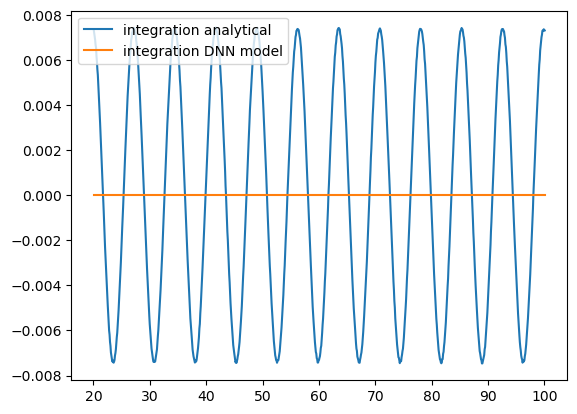

In [31]:
#plt.plot(x, u_t, label = "func")
plt.plot(x, s_t, label = "integration analytical")
plt.plot(x, p, label = "integration DNN model")
plt.legend()

In [ ]:
p